In [1]:
%pip install openpyxl pandas pytz


[notice] A new release of pip is available: 23.0.1 -> 24.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

In [2]:
data_file = "data/Slutrapport med distrikt.xlsx"

df = pd.read_excel(data_file)

In [4]:
## Fill in Titel
import time
df1 = df.astype({"Titel": str, "Annan info 2": str})

empty_idx = df1["Titel"].where(df1["Titel"] == "nan").index
fill_values_idx = df1["Annan info 2"].apply(lambda x: True if x.isdigit() else False)

for idx in df1.index:
    if df1["Titel"].iloc[idx] == "nan":
        if df1["Annan info 2"].iloc[idx].isdigit():
            df1.loc[idx, "Titel"] = str(df1["Annan info 2"].iloc[idx])

In [5]:
## Normalize Titel

df1["Titel"] = df1["Titel"].map(lambda x: x[:-2] if (x!="nan" and "." in(x)) else str(x))
df1["Titel"] = df1["Titel"].str.pad(8, "left", "0") 

In [6]:
## Age groupping
age_groups = {range(0, 18):"0-17",
              range(18,25):"18-24",
              range(25,35):"25-34",
              range(35,45):"35-44",
              range(45,55):"45-54",
              range(55,65):"55-64",
              range(65,75):"65-74"}

df1["Födelseår"] = df1["Födelseår"].fillna(0).astype(int)
all_ages = df1["Födelseår"].fillna(0).astype(int).to_list()

def get_replacement_ages(all_ages):
    replacement_ages = []
    for age in all_ages:
        for k, v in age_groups.items():
            if age in k:
                replacement_ages.append(v)
            
    return replacement_ages
    
replacement_ages = get_replacement_ages(all_ages)
df1["Födelseår"] = df1["Födelseår"].replace(all_ages, replacement_ages)

In [7]:
## Lag
from datetime import datetime
import pytz

election_date = datetime(year=2024, month=6, day=9).astimezone(pytz.UTC)
days_before_election = election_date - df1["Samtalstid"].dt.tz_localize("Europe/Stockholm")
days_before_election_rounded = round(days_before_election.dt.total_seconds() / 86400).astype(int)
df1['Days before election'] = days_before_election_rounded

In [20]:
df1.groupby(["Resultat", "Kön"])["Resultat"].count()

Resultat         Kön
Ej svar          K       2631
                 M        922
Ej vald          K      15696
                 M       6984
Fel nummer       K          8
                 M          1
Fortsatt samtal  K        102
                 M         52
Negativ          K       8208
                 M       4747
Positiv          K       9363
                 M       5792
Upptaget         K       3326
                 M       1472
Vet ej           K      17251
                 M       8233
Name: Resultat, dtype: int64

In [8]:
## Output

df1.to_csv("data/Slutrapport med distrikt cleaned.csv")

In [84]:
#### Calls and vote prop data
agg_results = pd.read_csv("data/n_calls.demographic_data.valdistrikt.csv")

In [85]:
agg_results

,Valdistriktskod,Valdistriktnamn,prop_of_valid_votes_S_2024,prop_of_valid_votes_C_2024,prop_of_valid_votes_KD_2024,prop_of_valid_votes_L_2024,prop_of_valid_votes_MP_2024,prop_of_valid_votes_M_2024,prop_of_valid_votes_SD_2024,prop_of_valid_votes_V_2024,...,prop_voting_M_2019,prop_voting_C_2019,prop_voting_L_2019,prop_voting_KD_2019,prop_voting_MP_2019,prop_voting_S_2019,prop_voting_V_2019,prop_voting_SD_2019,prop_voting_ÖVR_2019,n_calls
0,1140101,Övra Runby,0.287651,0.057229,0.043675,0.043675,0.149096,0.156627,0.146084,0.090361,...,0.525164,0.525164,0.525164,0.525164,0.525164,0.525164,0.525164,0.525164,0.525164,1.0
1,1140102,Mälaren,0.254019,0.073955,0.049839,0.038585,0.197749,0.172026,0.117363,0.083601,...,0.588828,0.588828,0.588828,0.588828,0.588828,0.588828,0.588828,0.588828,0.588828,NaN
2,1140120,Edssjön,0.276596,0.067103,0.034370,0.037643,0.142390,0.188216,0.116203,0.112930,...,0.461386,0.461386,0.461386,0.461386,0.461386,0.461386,0.461386,0.461386,0.461386,NaN
3,1140121,Nedra Runby,0.244718,0.066901,0.068662,0.024648,0.142606,0.151408,0.133803,0.140845,...,0.521352,0.521352,0.521352,0.521352,0.521352,0.521352,0.521352,0.521352,0.521352,NaN
4,1140126,Prästgårdsmarken,0.250000,0.054878,0.026423,0.016260,0.144309,0.099593,0.199187,0.164634,...,0.427386,0.427386,0.427386,0.427386,0.427386,0.427386,0.427386,0.427386,0.427386,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6270,25840010,Jukkasjärvi,0.259770,0.048276,0.135632,0.029885,0.085057,0.080460,0.172414,0.114943,...,0.435589,0.435589,0.435589,0.435589,0.435589,0.435589,0.435589,0.435589,0.435589,NaN
6271,25840011,Lombolo mellersta,0.433649,0.014218,0.082938,0.009479,0.068720,0.087678,0.080569,0.187204,...,0.424345,0.424345,0.424345,0.424345,0.424345,0.424345,0.424345,0.424345,0.424345,NaN
6272,25840012,Kiruna sydost,0.341404,0.031477,0.050847,0.016949,0.075061,0.062954,0.159806,0.242131,...,0.371232,0.371232,0.371232,0.371232,0.371232,0.371232,0.371232,0.371232,0.371232,51.0
6273,25840013,Luossavaara-Abisko,0.341837,0.032313,0.051020,0.011905,0.147959,0.078231,0.100340,0.221088,...,0.432387,0.432387,0.432387,0.432387,0.432387,0.432387,0.432387,0.432387,0.432387,16.0


In [93]:
import matplotlib.pyplot as plt

plot_data = agg_results[["prop_of_valid_votes_V_2024", "prop_of_valid_votes_V_2019", "n_calls"]]

In [94]:
plot_data

,prop_of_valid_votes_V_2024,prop_of_valid_votes_V_2019,n_calls
0,0.090361,0.069444,1.0
1,0.083601,0.054432,NaN
2,0.112930,0.062232,NaN
3,0.140845,0.076792,NaN
4,0.164634,0.121359,NaN
...,...,...,...
6270,0.114943,0.072340,NaN
6271,0.187204,0.121514,NaN
6272,0.242131,0.167053,51.0
6273,0.221088,0.162162,16.0


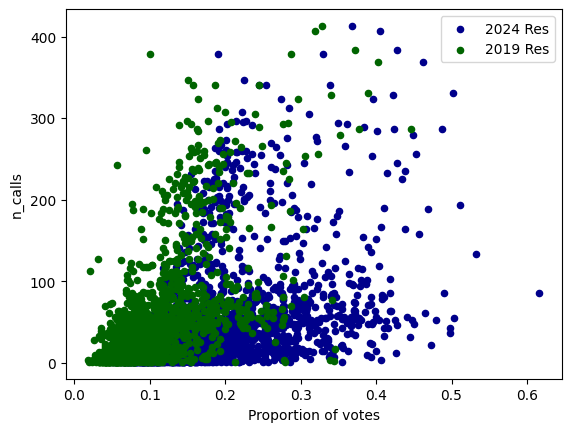

In [165]:
ax = plot_data.plot.scatter(x="prop_of_valid_votes_V_2024", y="n_calls", color="DarkBlue", label="2024 Res")
plot_data.plot.scatter(x="prop_of_valid_votes_V_2019", y="n_calls", color="DarkGreen", label="2019 Res", ax=ax);
plt.xlabel("Proportion of votes")
plt.savefig("plots/vote_share_2019_2024_vs_calls.png")

In [112]:
effective_idx = plot_data[
    (plot_data["n_calls"] < 100) &
    ((plot_data["prop_of_valid_votes_V_2024"] -  plot_data["prop_of_valid_votes_V_2019"]) > 0.05)
].index

improved_results = agg_results.loc[effective_idx]
improved_results["prop_change_V"] = improved_results["prop_of_valid_votes_V_2024"] -  improved_results["prop_of_valid_votes_V_2019"]

Text(0.5, 0, 'Proportion of change')

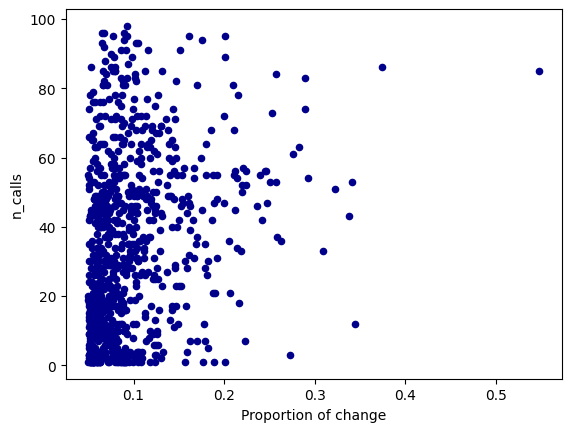

In [116]:
plot_improved_res = improved_results[["prop_change_V", "n_calls"]]
ax = plot_improved_res.plot.scatter(x="prop_change_V", y="n_calls", color="DarkBlue")
plt.xlabel("Proportion of change")

In [120]:
improved_results[["prop_change_V", "n_calls"]].corr()

,prop_change_V,n_calls
prop_change_V,1.000000,0.265616
n_calls,0.265616,1.000000


In [151]:
## Join with canvassing data
canv_data = df1.rename(columns={"Titel": "Valdistriktskod"})
canv_data["Valdistriktskod"] = canv_data["Valdistriktskod"].astype(str).str.pad(8, "left", "0")

agg_results["Valdistriktskod"] = agg_results["Valdistriktskod"].astype(str).str.pad(8, "left", "0")

join_data = pd.merge(canv_data, agg_results, on="Valdistriktskod", how="inner")

In [152]:
join_data

,Projektets kontor,Agentens användarnamn,Samtalstid,Samtalsriktning,Samtalslängd,Ringtid,Resultat,Kontaktlista,Annan info 1,Annan info 2,...,prop_voting_M_2019,prop_voting_C_2019,prop_voting_L_2019,prop_voting_KD_2019,prop_voting_MP_2019,prop_voting_S_2019,prop_voting_V_2019,prop_voting_SD_2019,prop_voting_ÖVR_2019,n_calls
0,Robot,Varmland6,2024-05-28 13:32:20,Inkommande,00:00:19,00:00:00,Vet ej,Robotlistan,0.071423,Karlshamn,...,0.602505,0.602505,0.602505,0.602505,0.602505,0.602505,0.602505,0.602505,0.602505,6.0
1,Robot,Varmland6,2024-05-28 13:33:28,Inkommande,00:00:34,00:00:00,Negativ,Robotlistan,0.180149,Karlskrona,...,0.285060,0.285060,0.285060,0.285060,0.285060,0.285060,0.285060,0.285060,0.285060,68.0
2,Robot,Varmland7,2024-05-28 13:36:32,Inkommande,00:00:08,00:00:00,Vet ej,Robotlistan,0.160903,Karlshamn,...,0.429383,0.429383,0.429383,0.429383,0.429383,0.429383,0.429383,0.429383,0.429383,46.0
3,Robot,Varmland8,2024-05-28 13:36:50,Inkommande,00:00:09,00:00:00,Negativ,Robotlistan,0.064147,Sölvesborg,...,0.441753,0.441753,0.441753,0.441753,0.441753,0.441753,0.441753,0.441753,0.441753,18.0
4,Robot,Varmland8,2024-05-28 13:39:27,Inkommande,00:00:20,00:00:01,Negativ,Robotlistan,0.076145,Karlskrona,...,0.462413,0.462413,0.462413,0.462413,0.462413,0.462413,0.462413,0.462413,0.462413,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83650,Robot,Storstockholm15,2024-06-09 13:10:50,Inkommande,00:00:05,00:00:01,Ej svar,Robotlistan,0.138977,nan,...,0.640530,0.640530,0.640530,0.640530,0.640530,0.640530,0.640530,0.640530,0.640530,8.0
83651,Robot,Storstockholm6,2024-06-09 13:53:11,Inkommande,00:00:04,00:00:01,Vet ej,Robotlistan,0.131566,#SAKNAS!,...,0.472469,0.472469,0.472469,0.472469,0.472469,0.472469,0.472469,0.472469,0.472469,29.0
83652,Robot,Storstockholm9,2024-06-09 13:53:15,Inkommande,00:00:04,00:00:01,Ej svar,Robotlistan,0.131566,#SAKNAS!,...,0.472469,0.472469,0.472469,0.472469,0.472469,0.472469,0.472469,0.472469,0.472469,29.0
83653,Robot,Uppsala2,2024-06-09 14:32:48,Utgående,00:00:00,00:00:23,Ej vald,Robotlistan,0.130580,nan,...,0.640530,0.640530,0.640530,0.640530,0.640530,0.640530,0.640530,0.640530,0.640530,8.0


In [160]:
## Join with deso data
deso_data = pd.read_csv("data/deso_vd_overlaps.csv", encoding='latin-1')
deso_data = deso_data.rename(columns={"Lkfv": "Valdistriktskod"})
deso_data["Valdistriktskod"] = deso_data["Valdistriktskod"].astype(str).str.pad(8, "left", "0")

join_data = pd.merge(join_data, deso_data, on="Valdistriktskod", how="inner")